In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

%matplotlib inline

In [2]:
#Loading the dataset
df = pd.read_csv(r"C:/Users/adaml/OneDrive/Documents/Data Projects/9 Projects for ITonlinelearning portfolio/Global_Superstore.csv")

In [3]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.98,2,0.0,62.15,40.77,High
1,26341,IN-2014-JR162107-41675,2/5/2014,2/7/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.40,9,0.1,-288.77,923.63,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.17,9,0.1,919.97,915.49,Medium
3,13524,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.51,5,0.1,-96.54,910.16,Medium
4,47221,SG-2014-RH9495111-41948,11/5/2014,11/6/2014,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.96,8,0.0,311.52,903.04,Critical


In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,1000.000000,194.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,25079.328000,53966.170103,1710.971470,5.55800,0.092840,288.920440,272.384897
std,12897.726632,33734.306466,1259.239238,2.71846,0.148666,574.504782,176.160716
min,58.000000,2920.000000,1.910000,1.00000,0.000000,-3059.820000,1.070000
25%,15118.750000,19134.000000,826.907500,4.00000,0.000000,10.037500,209.827500
50%,25084.500000,60564.000000,1585.115000,5.00000,0.000000,190.685000,258.897500
75%,34524.000000,88187.500000,2477.812500,7.00000,0.150000,518.872500,351.070250
max,51284.000000,98198.000000,9892.740000,14.00000,0.800000,4946.370000,923.630000


In [5]:
df.size
print(df.shape)

(1000, 24)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          1000 non-null   int64  
 1   Order ID        1000 non-null   str    
 2   Order Date      1000 non-null   str    
 3   Ship Date       1000 non-null   str    
 4   Ship Mode       1000 non-null   str    
 5   Customer ID     1000 non-null   str    
 6   Customer Name   1000 non-null   str    
 7   Segment         1000 non-null   str    
 8   Postal Code     194 non-null    float64
 9   City            1000 non-null   str    
 10  State           1000 non-null   str    
 11  Country         1000 non-null   str    
 12  Region          1000 non-null   str    
 13  Market          1000 non-null   str    
 14  Product ID      1000 non-null   str    
 15  Category        1000 non-null   str    
 16  Sub-Category    1000 non-null   str    
 17  Product Name    1000 non-null   str    
 18  

In [7]:
#Data cleaning - finding nulls
df.isnull().sum()

Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Postal Code       806
City                0
State               0
Country             0
Region              0
Market              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping Cost       0
Order Priority      0
dtype: int64

In [8]:
#data cleaning - dropping nulls from the dataframe
df.dropna(inplace=True)

In [9]:
#data cleaning - converting date types into datetime object
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

In [10]:
#Basic analysis - calculating total sales and profit
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
print(f'Total Sales: {total_sales}, Total Profit: {total_profit}')

Total Sales: 54535.08, Total Profit: 12063.97


In [11]:
#Basic analysis - identifying top-selling products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products

Product Name
GBC Ibimaster 500 Manual ProClick Binding System           9892.74
GBC DocuBind P400 Electric Binding System                  4355.17
Canon Image Class D660 Copier                              2999.95
GBC DocuBind 300 Electric Binding Machine                  2419.51
Hon 5100 Series Wood Tables                                2036.86
Bady BDG101FRU Card Printer                                1439.98
Avaya IP Phone 1140E VoIP phone                            1394.95
Global Adaptabilites Bookcase, Cherry/Storm Gray Finish    1292.94
Tennsco Single-Tier Lockers                                1126.02
Ibico Ibimaster 300 Manual Binding System                  1103.97
Name: Sales, dtype: float64

In [12]:
#Basic analysis - identifying sales by region
top_regions = df.groupby('Region')['Sales'].sum()
top_regions

Region
Central US     17187.94
Eastern US     12256.44
Southern US     8360.75
Western US     16729.95
Name: Sales, dtype: float64

In [13]:
#Basic analysis - relationship between sales and profit.
correlation = df['Sales'].corr(df['Profit'])
print(f'Correlation between Sales and Profit: {correlation}')

Correlation between Sales and Profit: 0.9313979948257132


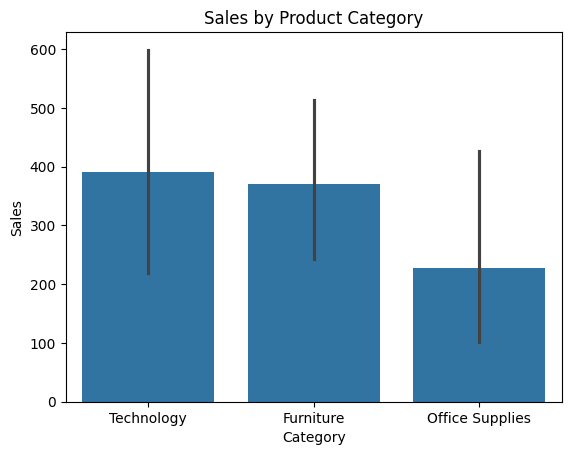

In [14]:
#bar plot of sales by product category
sns.barplot(x='Category', y='Sales',data=df)
plt.title('Sales by Product Category')
plt.show()

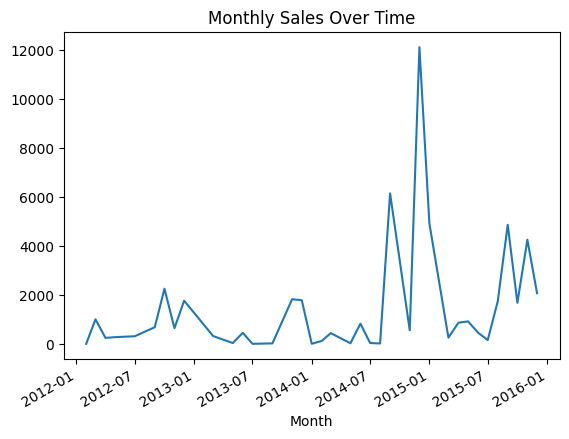

In [15]:
#Create a new 'Month' column from 'Order Date'
df['Month'] = df['Order Date'].dt.to_period('M')

#Calculate monthly sales
monthly_sales = df.groupby('Month')['Sales'].sum()

#Ensure the index is in datetime format for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

monthly_sales.plot(kind='line')
plt.title('Monthly Sales Over Time')
plt.show()

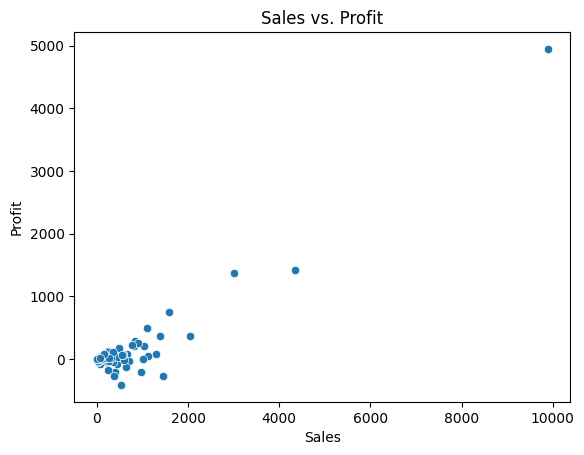

In [16]:
#Scatter plot of sales vs profit
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales vs. Profit')
plt.show()

[]

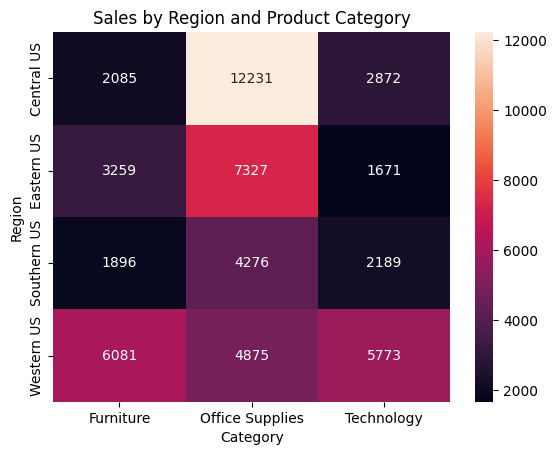

In [17]:
#heatmap - make pivot table for sales by Region and Product Category first
pivot_table = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')
    
sns.heatmap(pivot_table, annot=True, fmt='.0f')
plt.title('Sales by Region and Product Category')                        
plt.plot()                

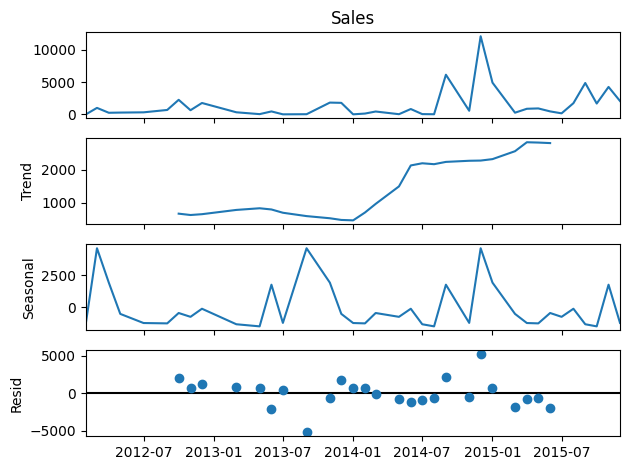

In [18]:
#Seasonal Decomposition of Time Series (monthly sales)
result = seasonal_decompose(monthly_sales, model='additive', period=12)
result.plot()
plt.show()

In [19]:
# Calculate total discount and total profit
total_discount = df['Discount'].sum()

# Convert 'Discount' and 'Profit' columns to numeric
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

# Calculate the correlation between discount and profit
discount_profit_correlation = df[['Discount', 'Profit']].corr().iloc[0,1]

total_discount, total_profit, discount_profit_correlation

(np.float64(29.95), np.float64(12063.97), np.float64(-0.16262271039478665))

##### Key Insights #####

- Technology products had the highest sales of all categories
- Monthly sales between July 2014 - Jan 2015 experienced sharp increases and decreases in sales, with Jan 2015 having the highest sales of 12000.
- Sales and Profit generally had a positive correlation.
- Office supplies was the highest category of sales in the Central US, Eastern US, and Southern US, with 12231 being the highest sales. Western US sales by category in comparison was more spread out.
- There is a negative correlation between discount and profit.


### Summary ###

##### Which product categories are the most profitable?
- Global Mart's sales data shows Technology leading, followed by Furniture, with Office supplies lagging. Technology has the highest sales and variability, while Office Supplies show consistent but lower performance. It may be worth investigating why Technology sales are more variable, and are affected by seasonal or other factors. Further analysis of sales patterns could help optimise Global Mart's product strategy and resource allocation, and provide insight on whether there is an opportunity to either boost Office supplies sales, or reduce focus on this category.  
##### Are there any noticeable trends in sales over time?
- Global Mart's sales show an overall upward trend from 2012 to 2016. A dramatic spike occurs in early 2015, reaching 12,000 units. After mid-2014, sales become more volatile with higher peaks. Early years show stability below 2,000 units monthly. Possible seasonal patterns emerge, through inconsistent. The 2015 spike marks a shift to higher, more variable sales, often exceeding 4,000 units monthly. The extreme peak in early 2015 could be due to a special event, promotion, or data anomaly, given how dramatically it differs from other periods - this is worth investigating the factors behind the sales spike.
##### How do sales and profits vary by region?
- Sales vary significantly across regions. Central US leads in Office Supplies (11,231 units), while Western US excels in Furniture and Technology (6,000 each). Eastern and Central US show strong Office Supplies sales. Furniture sales are lowest in Central and Southern US (2,085 units). Technology performs weakest in Eastern and Southern US. This regional variation suggests tailored strategies may be needed for each market to optimize sales performance.
##### Is there a correlation between discount and profit?
- Global Mart's data shows $29.95 in total discounts and $12,063.97 in total profit. The -0.16 correlation between discounts and profits indicates a weak inverse relationship. As discounts increase, profits slightly decrease, but the effect isn't strong. This suggests the current discount strategy minimally impacts overall profitability, but further analysis could optimise pricing for better results.
##### Are there any sales or seasonality trends?
- Sales show an overall increasing trend from 2012 to 2015, with significant volatility. A major sales spike occurs in early 2015, followed by continued fluctuations. Seasonal patterns are evident, with recurring peaks and troughs throughout the years. The trend line indicates a sharp increase in sales around mid-2014, which then stabilises at a higher level through 2015.